# Low-Resolution True Shifted-Lag Vecchia Simulation

Simulation-only diagnostic: the true longitudinal advection is known, so the lagged conditioning neighborhoods can be shifted by the true upstream displacement. The grid uses latitude resolution x4 and longitude resolution x2, so the true lag-1 longitudinal shift 0.126 is exactly one longitude cell.


In [1]:
import os
import sys
import time
import io
import contextlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.fft
import matplotlib.pyplot as plt

AMAREL_SRC = "/home/jl2815/tco"
LOCAL_SRC = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

from GEMS_TCO import kernels_vecchia
from GEMS_TCO import kernels_vecchia_advec_band
from GEMS_TCO import kernels_vecchia_shifted_lag
from GEMS_TCO import orderings as _orderings

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64

# Low-resolution shifted-lag test: lat x4, lon x2.
DELTA_LAT = 0.044 * 4
DELTA_LON = 0.063 * 2
T_STEPS = 8

print("DEVICE:", DEVICE)
print("SRC:", _src)
print("Grid resolution:", DELTA_LAT, DELTA_LON)



DEVICE: cpu
SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
Grid resolution: 0.176 0.126


## Settings And Model Groups


In [2]:
LAT_RANGE = (-3.0, 2.0)
LON_RANGE = (121.0, 131.0)
MC_NUM_ITERS = 30
SEED = 42

SMOOTH = 0.5
MM_COND_NUMBER = 100
NHEADS = 0
DAILY_STRIDE = 2

LBFGS_STEPS = 5
LBFGS_EVAL = 20
LBFGS_HIST = 10
INIT_NOISE = 0.7
SUPPRESS_FIT_PRINTS = True

RUN_ONE_SHOT_GODAMBE = True
HESSIAN_EPS = 1e-4
SCORE_EPS = 1e-5
H_RIDGE_SCALE = 1e-6
GODAMBE_J_METHOD = "block"
GODAMBE_BLOCK_LAT_WIDTH = 0.50
GODAMBE_BLOCK_LON_WIDTH = 0.50
GODAMBE_BLOCK_TIME_WIDTH = 2.0

TRUE_DICT = {
    "sigmasq": 10.0,
    "range_lat": 0.30,
    "range_lon": 0.40,
    "range_time": 2.0,
    "advec_lat": 0.08,
    "advec_lon": -0.126,
    "nugget": 2.5,
}

# Current point at time t corresponds to an upstream point eastward at previous times.
TRUE_LAG1_LON_SHIFT = abs(TRUE_DICT["advec_lon"])
TRUE_LAG2_LON_SHIFT = 2.0 * abs(TRUE_DICT["advec_lon"])
TRUE_LAG1_LAT_SHIFT = 0.0
TRUE_LAG2_LAT_SHIFT = 0.0
print(f"lon step = {DELTA_LON:.3f}; lag1 true lon shift = {TRUE_LAG1_LON_SHIFT:.3f} ({TRUE_LAG1_LON_SHIFT / DELTA_LON:.1f} cells)")
print(f"lag2 true lon shift = {TRUE_LAG2_LON_SHIFT:.3f} ({TRUE_LAG2_LON_SHIFT / DELTA_LON:.1f} cells)")

BASE_A = 12
BASE_B = 12
BASE_C = 6

def total_conditioning(a, b=0, c=0, uses_lag1=True, uses_lag2=True):
    total = int(a)
    if uses_lag1:
        total += int(1 + b)
    if uses_lag2:
        total += int(1 + c)
    return total

def std_spec(name, a, b, c, group, allocation, daily_stride=DAILY_STRIDE, uses_lag2=True):
    return {
        "name": name,
        "group": group,
        "kernel": "std",
        "limit_A": int(a),
        "limit_B": int(b),
        "limit_C": int(c),
        "daily_stride": int(daily_stride),
        "uses_lag2": bool(uses_lag2),
        "lag1_lon_shift": 0.0,
        "lag2_lon_shift": 0.0,
        "lag1_lat_shift": 0.0,
        "lag2_lat_shift": 0.0,
        "lag1_ratio_actual": float(b / a) if a else np.nan,
        "lag2_ratio_actual": float(c / a) if (a and uses_lag2) else 0.0,
        "total_conditioning": total_conditioning(a, b, c, uses_lag1=True, uses_lag2=uses_lag2),
        "allocation": allocation,
        "description": f"t: {a}; t-1: same loc + {b} local; t-2: same loc + {c} local",
    }

def shifted_spec(name, a, b, c, group, allocation):
    return {
        "name": name,
        "group": group,
        "kernel": "shifted_lag",
        "limit_A": int(a),
        "limit_B": int(b),
        "limit_C": int(c),
        "daily_stride": DAILY_STRIDE,
        "uses_lag2": True,
        "lag1_lon_shift": TRUE_LAG1_LON_SHIFT,
        "lag2_lon_shift": TRUE_LAG2_LON_SHIFT,
        "lag1_lat_shift": TRUE_LAG1_LAT_SHIFT,
        "lag2_lat_shift": TRUE_LAG2_LAT_SHIFT,
        "lag1_ratio_actual": float(b / a) if a else np.nan,
        "lag2_ratio_actual": float(c / a) if a else np.nan,
        "total_conditioning": total_conditioning(a, b, c, uses_lag1=True, uses_lag2=True),
        "allocation": allocation,
        "description": f"t: {a}; t-1: true-shifted target + {b} shifted current-neighbor locations; t-2: true-shifted target + {c} shifted current-neighbor locations",
    }

EXPERIMENT_GROUPS = {
    "true_shift_lag": [
        std_spec("BaseLocal_A12_B12_C06", BASE_A, BASE_B, BASE_C, "true_shift_lag", "local lagged neighborhoods"),
        shifted_spec("TrueShiftLag_A12_B12_C06", BASE_A, BASE_B, BASE_C, "true_shift_lag", "true advection-shifted lag neighborhoods"),
    ]
}

ACTIVE_GROUPS = ["true_shift_lag"]

MODEL_SPECS = {}
for group_name in ACTIVE_GROUPS:
    for spec in EXPERIMENT_GROUPS[group_name]:
        key = f"{group_name}::{spec['name']}"
        MODEL_SPECS[key] = spec

spec_df = pd.DataFrame(MODEL_SPECS).T
print("Active groups:", ACTIVE_GROUPS)
print("Number of model fits per MC iteration:", len(MODEL_SPECS))
display(spec_df[["group", "kernel", "limit_A", "limit_B", "limit_C", "lag1_lon_shift", "lag2_lon_shift", "daily_stride", "allocation", "lag1_ratio_actual", "lag2_ratio_actual", "total_conditioning", "description"]])



lon step = 0.126; lag1 true lon shift = 0.126 (1.0 cells)
lag2 true lon shift = 0.252 (2.0 cells)
Active groups: ['true_shift_lag']
Number of model fits per MC iteration: 2


,group,kernel,limit_A,limit_B,limit_C,lag1_lon_shift,lag2_lon_shift,daily_stride,allocation,lag1_ratio_actual,lag2_ratio_actual,total_conditioning,description
true_shift_lag::BaseLocal_A12_B12_C06,true_shift_lag,std,12,12,6,0.0,0.0,2,local lagged neighborhoods,1.0,0.5,32,t: 12; t-1: same loc + 12 local; t-2: same loc...
true_shift_lag::TrueShiftLag_A12_B12_C06,true_shift_lag,shifted_lag,12,12,6,0.126,0.252,2,true advection-shifted lag neighborhoods,1.0,0.5,32,t: 12; t-1: true-shifted target + 12 shifted c...


## Simulation Helpers


In [3]:
P_LABELS = ["sigmasq", "range_lat", "range_lon", "range_time", "advec_lat", "advec_lon", "nugget"]
P_COLS = ["sigmasq_est", "range_lat_est", "range_lon_est", "range_t_est", "advec_lat_est", "advec_lon_est", "nugget_est"]
SPATIAL_KEYS = ["sigmasq", "range_lat", "range_lon"]
ADVECTION_KEYS = ["advec_lat", "advec_lon"]

def transform_log_phi_to_physical(p):
    phi1, phi2, phi3, phi4 = (torch.exp(p[i]) for i in range(4))
    rlon = 1.0 / phi2
    return torch.stack([
        phi1 / phi2,
        rlon / torch.sqrt(phi3),
        rlon,
        rlon / torch.sqrt(phi4),
        p[4],
        p[5],
        torch.exp(p[6]),
    ])

def get_covariance_on_grid(lx, ly, lt, params):
    params = torch.clamp(params, min=-15.0, max=15.0)
    phi1, phi2, phi3, phi4 = (torch.exp(params[i]) for i in range(4))
    u_lat = lx - params[4] * lt
    u_lon = ly - params[5] * lt
    dist = torch.sqrt(u_lat.pow(2) * phi3 + u_lon.pow(2) + lt.pow(2) * phi4 + 1e-8)
    return (phi1 / phi2) * torch.exp(-dist * phi2)

def build_target_grid(lat_range, lon_range):
    lat0, lat1 = float(min(lat_range)), float(max(lat_range))
    lon0, lon1 = float(min(lon_range)), float(max(lon_range))
    n_lat = int(np.floor((lat1 - lat0) / DELTA_LAT + 1e-9)) + 1
    n_lon = int(np.floor((lon1 - lon0) / DELTA_LON + 1e-9)) + 1
    lats = lat0 + torch.arange(n_lat, device=DEVICE, dtype=DTYPE) * DELTA_LAT
    lons = lon0 + torch.arange(n_lon, device=DEVICE, dtype=DTYPE) * DELTA_LON
    lats = torch.round(lats * 10000) / 10000
    lons = torch.round(lons * 10000) / 10000
    g_lat, g_lon = torch.meshgrid(lats, lons, indexing="ij")
    grid_coords = torch.stack([g_lat.flatten(), g_lon.flatten()], dim=1)
    return lats, lons, grid_coords

def grid_resolution_report(lats, lons):
    lat_d = torch.diff(lats).detach().cpu().numpy()
    lon_d = torch.diff(lons).detach().cpu().numpy()
    return {
        "lat_min_step": float(lat_d.min()) if len(lat_d) else np.nan,
        "lat_max_step": float(lat_d.max()) if len(lat_d) else np.nan,
        "lon_min_step": float(lon_d.min()) if len(lon_d) else np.nan,
        "lon_max_step": float(lon_d.max()) if len(lon_d) else np.nan,
        "lat_first_last": (float(lats[0]), float(lats[-1])),
        "lon_first_last": (float(lons[0]), float(lons[-1])),
    }

def generate_field_values(n_lat, n_lon, t_steps, params):
    cpu = torch.device("cpu")
    f32 = torch.float32
    px, py, pt = 2 * n_lat, 2 * n_lon, 2 * t_steps
    lx = torch.arange(px, device=cpu, dtype=f32) * DELTA_LAT
    lx[px // 2:] -= px * DELTA_LAT
    ly = torch.arange(py, device=cpu, dtype=f32) * DELTA_LON
    ly[py // 2:] -= py * DELTA_LON
    lt = torch.arange(pt, device=cpu, dtype=f32)
    lt[pt // 2:] -= pt
    params_cpu = params.cpu().float()
    Lx, Ly, Lt = torch.meshgrid(lx, ly, lt, indexing="ij")
    C = get_covariance_on_grid(Lx, Ly, Lt, params_cpu)
    S = torch.fft.fftn(C)
    S.real = torch.clamp(S.real, min=0)
    noise = torch.fft.fftn(torch.randn(px, py, pt, device=cpu, dtype=f32))
    field = torch.fft.ifftn(torch.sqrt(S.real) * noise).real[:n_lat, :n_lon, :t_steps]
    return field.to(device=DEVICE, dtype=DTYPE)

def assemble_reg_map(field, grid_coords, true_params, t_offset=21.0):
    nugget_std = torch.sqrt(torch.exp(true_params[6]))
    n_grid = grid_coords.shape[0]
    field_flat = field.reshape(n_grid, field.shape[-1])
    reg_map = {}
    for t_idx in range(field.shape[-1]):
        key = f"t{t_idx}"
        t_val = float(t_offset + t_idx)
        dummy = torch.zeros(7, device=DEVICE, dtype=DTYPE)
        if t_idx > 0:
            dummy[t_idx - 1] = 1.0
        rows = torch.zeros((n_grid, 11), device=DEVICE, dtype=DTYPE)
        rows[:, :2] = grid_coords
        rows[:, 2] = field_flat[:, t_idx] + torch.randn(n_grid, device=DEVICE, dtype=DTYPE) * nugget_std
        rows[:, 3] = t_val
        rows[:, 4:] = dummy.unsqueeze(0).expand(n_grid, -1)
        reg_map[key] = rows.detach()
    return reg_map

def compute_grid_ordering(grid_coords, mm_cond_number):
    coords_np = grid_coords.detach().cpu().numpy()
    ord_mm = _orderings.maxmin_cpp(coords_np)
    nns = _orderings.find_nns_l2(locs=coords_np[ord_mm], max_nn=mm_cond_number)
    return ord_mm, nns

def true_to_log_params(true_dict):
    phi2 = 1.0 / true_dict["range_lon"]
    phi1 = true_dict["sigmasq"] * phi2
    phi3 = (true_dict["range_lon"] / true_dict["range_lat"]) ** 2
    phi4 = (true_dict["range_lon"] / true_dict["range_time"]) ** 2
    return [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4), true_dict["advec_lat"], true_dict["advec_lon"], np.log(true_dict["nugget"])]

def backmap_params(out_params):
    p = [x.item() if isinstance(x, torch.Tensor) else float(x) for x in out_params[:7]]
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    rlon = 1.0 / phi2
    return {
        "sigmasq": np.exp(p[0]) / phi2,
        "range_lat": rlon / phi3 ** 0.5,
        "range_lon": rlon,
        "range_time": rlon / phi4 ** 0.5,
        "advec_lat": p[4],
        "advec_lon": p[5],
        "nugget": np.exp(p[6]),
    }

def rmsre_for_keys(est, true_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        tv = true_dict[key]
        ev = est[key]
        if abs(tv) >= zero_thresh:
            vals.append(((ev - tv) / abs(tv)) ** 2)
        else:
            vals.append(abs(ev - tv) ** 2)
    return float(np.sqrt(np.mean(vals)))

def relative_se_summary(se_by_key, denom_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        denom = abs(denom_dict[key])
        if denom >= zero_thresh:
            vals.append((se_by_key[key] / denom) ** 2)
        else:
            vals.append(se_by_key[key] ** 2)
    return float(np.sqrt(np.mean(vals)))

def calculate_metrics(out_params, true_dict):
    est = backmap_params(out_params)
    return {
        "overall_rmsre": rmsre_for_keys(est, true_dict, P_LABELS),
        "spatial_rmsre": rmsre_for_keys(est, true_dict, SPATIAL_KEYS),
        "range_time_re": abs(est["range_time"] - true_dict["range_time"]) / abs(true_dict["range_time"]),
        "advec_rmsre": rmsre_for_keys(est, true_dict, ADVECTION_KEYS),
        "nugget_re": abs(est["nugget"] - true_dict["nugget"]) / abs(true_dict["nugget"]),
        "est": est,
    }

def make_random_init(rng, true_log, init_noise):
    noisy = list(true_log)
    for i in [0, 1, 2, 3, 6]:
        noisy[i] = true_log[i] + rng.uniform(-init_noise, init_noise)
    for i in [4, 5]:
        scale = max(abs(true_log[i]), 0.05)
        noisy[i] = true_log[i] + rng.uniform(-2 * scale, 2 * scale)
    return noisy


## Optional Godambe Helpers


In [4]:
def finite_diff_hessian(nll_fn, p, eps=HESSIAN_EPS):
    n = p.shape[0]
    H = torch.zeros(n, n, device=p.device, dtype=p.dtype)
    for i in range(n):
        p_p = p.detach().clone(); p_m = p.detach().clone()
        p_p[i] += eps; p_m[i] -= eps
        p_p.requires_grad_(True); p_m.requires_grad_(True)
        g_p = torch.autograd.grad(nll_fn(p_p), p_p)[0].detach()
        g_m = torch.autograd.grad(nll_fn(p_m), p_m)[0].detach()
        H[i] = (g_p - g_m) / (2.0 * eps)
    return (H + H.T) / 2.0

def vecchia_per_unit_target_coords(model):
    chunks = []
    if model.Heads_data is not None and model.Heads_data.shape[0] > 0:
        chunks.append(model.Heads_data[:, [0, 1, 3]].to(dtype=DTYPE))
    for X_b in [model.X_A, model.X_AB, model.X_ABC]:
        if X_b is not None and X_b.shape[0] > 0:
            chunks.append(X_b[:, -1, :].to(dtype=DTYPE))
    if not chunks:
        return torch.empty((0, 3), device=DEVICE, dtype=DTYPE)
    return torch.cat(chunks, dim=0)

def make_block_ids(target_coords):
    lat = target_coords[:, 0]
    lon = target_coords[:, 1]
    tim = target_coords[:, 2]
    lat_id = torch.floor((lat - lat.min()) / GODAMBE_BLOCK_LAT_WIDTH).to(torch.long)
    lon_id = torch.floor((lon - lon.min()) / GODAMBE_BLOCK_LON_WIDTH).to(torch.long)
    if GODAMBE_BLOCK_TIME_WIDTH is None or GODAMBE_BLOCK_TIME_WIDTH <= 0:
        time_id = torch.zeros_like(lat_id)
    else:
        time_id = torch.floor((tim - tim.min()) / GODAMBE_BLOCK_TIME_WIDTH).to(torch.long)
    n_lon = int(lon_id.max().item()) + 1 if lon_id.numel() else 1
    n_time = int(time_id.max().item()) + 1 if time_id.numel() else 1
    raw_id = (lat_id * n_lon + lon_id) * n_time + time_id
    _, block_id = torch.unique(raw_id, sorted=True, return_inverse=True)
    return block_id

def score_cov_per_unit_centered(score_mat):
    n_units = score_mat.shape[1]
    score_mean = score_mat.mean(dim=1)
    score_centered = score_mat - score_mean.unsqueeze(1)
    if n_units > 1:
        return score_centered @ score_centered.T / (n_units * (n_units - 1))
    return score_mat @ score_mat.T / max(n_units ** 2, 1)

def score_cov_block_cluster(score_mat, target_coords):
    n_units = score_mat.shape[1]
    scores = score_mat.T.contiguous()
    block_id = make_block_ids(target_coords)
    n_blocks = int(block_id.max().item()) + 1 if block_id.numel() else 0
    block_scores = torch.zeros((n_blocks, scores.shape[1]), device=DEVICE, dtype=DTYPE)
    block_scores.index_add_(0, block_id, scores)
    if n_blocks > 1:
        centered = block_scores - block_scores.mean(dim=0, keepdim=True)
        J = centered.T @ centered * (n_blocks / (n_blocks - 1)) / (n_units ** 2)
    else:
        J = block_scores.T @ block_scores / max(n_units ** 2, 1)
    return J, n_blocks

def compute_vecchia_godambe(model, raw_params):
    p_hat = torch.tensor(raw_params[:7], device=DEVICE, dtype=DTYPE, requires_grad=True)

    def nll(p):
        return model.vecchia_batched_likelihood(p)

    H = finite_diff_hessian(nll, p_hat)
    eig = torch.linalg.eigvalsh(H).detach()
    h_abs_min = torch.clamp(torch.min(torch.abs(eig)), min=1e-12)
    h_cond = float((torch.max(torch.abs(eig)) / h_abs_min).detach().cpu())
    beta_hat = model.get_gls_beta(p_hat).detach()

    def per_unit_losses(p):
        return model.vecchia_per_unit_nll_terms(p, beta_hat)

    cols = []
    for k in range(p_hat.shape[0]):
        pp = p_hat.detach().clone(); pm = p_hat.detach().clone()
        pp[k] += SCORE_EPS; pm[k] -= SCORE_EPS
        with torch.no_grad():
            cols.append((per_unit_losses(pp) - per_unit_losses(pm)) / (2.0 * SCORE_EPS))
    score_mat = torch.stack(cols)
    n_units = score_mat.shape[1]
    target_coords = vecchia_per_unit_target_coords(model)
    if target_coords.shape[0] != n_units:
        raise RuntimeError(f"target/score mismatch: targets={target_coords.shape[0]}, scores={n_units}")

    score_mean = score_mat.mean(dim=1)
    p_grad = p_hat.detach().clone().requires_grad_(True)
    profile_grad = torch.autograd.grad(nll(p_grad), p_grad)[0].detach()
    score_grad_diff = profile_grad - score_mean

    J_uncentered = score_mat @ score_mat.T / (n_units ** 2)
    J_centered = score_cov_per_unit_centered(score_mat)
    J_block, n_blocks = score_cov_block_cluster(score_mat, target_coords)
    if GODAMBE_J_METHOD == "block":
        J_main = J_block
    elif GODAMBE_J_METHOD == "per_unit_centered":
        J_main = J_centered
    elif GODAMBE_J_METHOD == "per_unit_uncentered":
        J_main = J_uncentered
    else:
        raise ValueError(f"Unknown GODAMBE_J_METHOD={GODAMBE_J_METHOD!r}")

    eye = torch.eye(H.shape[0], device=DEVICE, dtype=DTYPE)
    h_scale = torch.clamp(torch.mean(torch.abs(torch.diag(H))), min=1.0)
    H_inv = torch.linalg.pinv(H + eye * h_scale * H_RIDGE_SCALE)
    Jac = torch.autograd.functional.jacobian(transform_log_phi_to_physical, p_hat)

    def summarize_J(J):
        G_raw = H_inv @ J @ H_inv
        G_phys = Jac @ G_raw @ Jac.T
        se = torch.sqrt(torch.clamp(torch.diag(G_phys), min=0.0)).detach().cpu().numpy()
        se_by_key = dict(zip(P_LABELS, [float(x) for x in se]))
        return se_by_key, {
            "spatial": relative_se_summary(se_by_key, TRUE_DICT, SPATIAL_KEYS),
            "overall": relative_se_summary(se_by_key, TRUE_DICT, P_LABELS),
            "advec": relative_se_summary(se_by_key, TRUE_DICT, ADVECTION_KEYS),
            "nugget": se_by_key["nugget"] / abs(TRUE_DICT["nugget"]),
        }

    se_main, rel_main = summarize_J(J_main)
    se_block, rel_block = summarize_J(J_block)
    se_centered, rel_centered = summarize_J(J_centered)
    se_uncentered, rel_uncentered = summarize_J(J_uncentered)
    return {
        "gim_j_method": GODAMBE_J_METHOD,
        "gim_n_units": int(n_units),
        "gim_n_blocks": int(n_blocks),
        "gim_h_cond_abs": h_cond,
        "gim_score_mean_max_abs": float(torch.max(torch.abs(score_mean)).detach().cpu()),
        "gim_profile_grad_max_abs": float(torch.max(torch.abs(profile_grad)).detach().cpu()),
        "gim_score_profile_diff_max_abs": float(torch.max(torch.abs(score_grad_diff)).detach().cpu()),
        "gim_spatial_rel_se": rel_main["spatial"],
        "gim_overall_rel_se": rel_main["overall"],
        "gim_advec_rel_se": rel_main["advec"],
        "gim_nugget_rel_se": rel_main["nugget"],
        "gim_spatial_rel_se_block": rel_block["spatial"],
        "gim_spatial_rel_se_perunit_centered": rel_centered["spatial"],
        "gim_spatial_rel_se_uncentered": rel_uncentered["spatial"],
        **{f"gim_se_{k}": v for k, v in se_main.items()},
    }


## Fit And Monte Carlo


In [5]:
def fit_vecchia_spec(model_key, spec, reg_map_ord, nns_grid, ordered_grid_coords_np, initial_vals, compute_godambe=False):
    params = [torch.tensor([val], device=DEVICE, dtype=DTYPE, requires_grad=True) for val in initial_vals]
    daily_stride = int(spec.get("daily_stride", DAILY_STRIDE))
    if spec["kernel"] == "std":
        model = kernels_vecchia.fit_vecchia_lbfgs(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["limit_B"],
            limit_C=spec["limit_C"],
            daily_stride=daily_stride,
        )
    elif spec["kernel"] == "advec_band":
        model = kernels_vecchia_advec_band.fit_vecchia_lbfgs_advec_band(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["limit_B"],
            limit_C=spec["limit_C"],
            daily_stride=daily_stride,
            spatial_coords=ordered_grid_coords_np,
            lon_resolution=spec.get("lon_resolution", DELTA_LON),
            advec_cell_offsets=spec.get("advec_cell_offsets", (2, 3)),
        )
    elif spec["kernel"] == "shifted_lag":
        model = kernels_vecchia_shifted_lag.fit_vecchia_lbfgs_shifted_lag(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["limit_B"],
            limit_C=spec["limit_C"],
            daily_stride=daily_stride,
            spatial_coords=ordered_grid_coords_np,
            lag1_lon_shift=spec.get("lag1_lon_shift", TRUE_LAG1_LON_SHIFT),
            lag2_lon_shift=spec.get("lag2_lon_shift", TRUE_LAG2_LON_SHIFT),
            lag1_lat_shift=spec.get("lag1_lat_shift", 0.0),
            lag2_lat_shift=spec.get("lag2_lat_shift", 0.0),
        )
    else:
        raise ValueError(f"Unknown kernel: {spec['kernel']}")

    t0 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            model.precompute_conditioning_sets()
    else:
        model.precompute_conditioning_sets()
    precompute_s = time.time() - t0

    optimizer = model.set_optimizer(params, lr=1.0, max_iter=LBFGS_EVAL, history_size=LBFGS_HIST)
    t1 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    else:
        out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    fit_s = time.time() - t1

    metrics = calculate_metrics(out, TRUE_DICT)
    godambe = {}
    gim_s = 0.0
    if compute_godambe:
        t2 = time.time()
        godambe = compute_vecchia_godambe(model, [float(x) for x in out[:7]])
        gim_s = time.time() - t2
    return out, float(out[-1]), int(n_iter), precompute_s, fit_s, gim_s, metrics, godambe

def run_experiment(num_iters=MC_NUM_ITERS, seed=SEED, compute_godambe=False, save_csv=True, csv_name=None):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    true_log = true_to_log_params(TRUE_DICT)
    true_params = torch.tensor(true_log, device=DEVICE, dtype=DTYPE)
    lats_grid, lons_grid, grid_coords = build_target_grid(LAT_RANGE, LON_RANGE)
    n_lat, n_lon = len(lats_grid), len(lons_grid)
    print(f"Grid: {n_lat} x {n_lon} x {T_STEPS} = {n_lat * n_lon * T_STEPS:,} rows")
    print("Actual resolution:", grid_resolution_report(lats_grid, lons_grid))
    print("Model specs:")
    display(pd.DataFrame(MODEL_SPECS).T[["group", "kernel", "limit_A", "limit_B", "limit_C", "daily_stride", "uses_lag2", "allocation", "total_conditioning", "description"]])
    ord_grid, nns_grid = compute_grid_ordering(grid_coords, MM_COND_NUMBER)
    ordered_grid_coords_np = grid_coords[ord_grid].detach().cpu().numpy()
    print("Ordering done")

    records = []
    for it in range(num_iters):
        print(f"\n=== Iteration {it + 1}/{num_iters} ===")
        initial_vals = make_random_init(rng, true_log, INIT_NOISE)
        field = generate_field_values(n_lat, n_lon, T_STEPS, true_params)
        reg_map = assemble_reg_map(field, grid_coords, true_params)
        del field
        reg_map_ord = {k: v[ord_grid] for k, v in reg_map.items()}
        for model_key, spec in MODEL_SPECS.items():
            try:
                print(f"{model_key}: fitting", end="")
                out, loss, n_iter, pre_s, fit_s, gim_s, metrics, godambe = fit_vecchia_spec(
                    model_key, spec, reg_map_ord, nns_grid, ordered_grid_coords_np, initial_vals, compute_godambe=compute_godambe
                )
                est = metrics.pop("est")
                row = {
                    "iter": it + 1,
                    "model_key": model_key,
                    "model": spec["name"],
                    "group": spec["group"],
                    "kernel": spec["kernel"],
                    "allocation": spec["allocation"],
                    "limit_A": spec["limit_A"],
                    "limit_B": spec["limit_B"],
                    "limit_C": spec["limit_C"],
                    "daily_stride": spec.get("daily_stride", DAILY_STRIDE),
                    "uses_lag2": spec.get("uses_lag2", True),
                    "advec_cell_offsets": ",".join(map(str, spec.get("advec_cell_offsets", ()))),
                    "lag1_lon_shift": spec.get("lag1_lon_shift", 0.0),
                    "lag2_lon_shift": spec.get("lag2_lon_shift", 0.0),
                    "lag1_ratio_actual": spec["lag1_ratio_actual"],
                    "lag2_ratio_actual": spec["lag2_ratio_actual"],
                    "total_conditioning": spec["total_conditioning"],
                    "loss": round(loss, 6),
                    "overall_rmsre": round(metrics["overall_rmsre"], 6),
                    "spatial_rmsre": round(metrics["spatial_rmsre"], 6),
                    "range_time_re": round(metrics["range_time_re"], 6),
                    "advec_rmsre": round(metrics["advec_rmsre"], 6),
                    "nugget_re": round(metrics["nugget_re"], 6),
                    "precompute_s": round(pre_s, 3),
                    "fit_s": round(fit_s, 3),
                    "gim_s": round(gim_s, 3),
                    "total_s": round(pre_s + fit_s + gim_s, 3),
                    "fit_iter": n_iter,
                }
                row.update({
                    "sigmasq_est": round(est["sigmasq"], 6),
                    "range_lat_est": round(est["range_lat"], 6),
                    "range_lon_est": round(est["range_lon"], 6),
                    "range_t_est": round(est["range_time"], 6),
                    "advec_lat_est": round(est["advec_lat"], 6),
                    "advec_lon_est": round(est["advec_lon"], 6),
                    "nugget_est": round(est["nugget"], 6),
                })
                row.update(godambe)
                records.append(row)
                print(f" | loss={loss:.4f} spatial={metrics['spatial_rmsre']:.4f} overall={metrics['overall_rmsre']:.4f} time={pre_s + fit_s + gim_s:.1f}s")
            except Exception as exc:
                print(f" | FAILED: {type(exc).__name__}: {exc}")
                records.append({"iter": it + 1, "model_key": model_key, "model": spec.get("name", model_key), "group": spec.get("group"), "error": repr(exc)})
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    df = pd.DataFrame(records)
    if save_csv:
        out_dir = Path("log")
        out_dir.mkdir(exist_ok=True)
        if csv_name is None:
            csv_name = "sim_vecchia_lowres_x4_all_tests_results.csv"
        out_path = out_dir / csv_name
        df.to_csv(out_path, index=False)
        print("Saved:", out_path)
    return df



## Optional One-Shot Godambe


In [6]:
if RUN_ONE_SHOT_GODAMBE:
    df_godambe = run_experiment(
        num_iters=1,
        seed=SEED,
        compute_godambe=True,
        save_csv=True,
        csv_name="sim_vecchia_lowres_x4_lonx2_true_shift_lag_godambe_043026_results.csv",
    )
    display(df_godambe.sort_values(["group", "gim_spatial_rel_se"]))
else:
    df_godambe = pd.DataFrame()
    print("Skipping one-shot Godambe. Set RUN_ONE_SHOT_GODAMBE=True to run it.")




Grid: 29 x 80 x 8 = 18,560 rows
Actual resolution: {'lat_min_step': 0.1759999999999997, 'lat_max_step': 0.17600000000000016, 'lon_min_step': 0.12599999999997635, 'lon_max_step': 0.12600000000000477, 'lat_first_last': (-3.0, 1.928), 'lon_first_last': (121.0, 130.954)}
Model specs:


,group,kernel,limit_A,limit_B,limit_C,daily_stride,uses_lag2,allocation,total_conditioning,description
true_shift_lag::BaseLocal_A12_B12_C06,true_shift_lag,std,12,12,6,2,True,local lagged neighborhoods,32,t: 12; t-1: same loc + 12 local; t-2: same loc...
true_shift_lag::TrueShiftLag_A12_B12_C06,true_shift_lag,shifted_lag,12,12,6,2,True,true advection-shifted lag neighborhoods,32,t: 12; t-1: true-shifted target + 12 shifted c...


Ordering done

=== Iteration 1/1 ===
true_shift_lag::BaseLocal_A12_B12_C06: fitting | loss=1.5455 spatial=0.0105 overall=0.0347 time=22.8s
true_shift_lag::TrueShiftLag_A12_B12_C06: fitting | loss=1.5456 spatial=0.2004 overall=0.1823 time=20.9s
Saved: log/sim_vecchia_lowres_x4_lonx2_true_shift_lag_godambe_043026_results.csv


,iter,model_key,model,group,kernel,allocation,limit_A,limit_B,limit_C,daily_stride,...,gim_spatial_rel_se_block,gim_spatial_rel_se_perunit_centered,gim_spatial_rel_se_uncentered,gim_se_sigmasq,gim_se_range_lat,gim_se_range_lon,gim_se_range_time,gim_se_advec_lat,gim_se_advec_lon,gim_se_nugget
0,1,true_shift_lag::BaseLocal_A12_B12_C06,BaseLocal_A12_B12_C06,true_shift_lag,std,local lagged neighborhoods,12,12,6,2,...,0.075127,0.040104,0.040103,0.546974,0.025414,0.032898,0.183267,0.007541,0.010391,0.231775
1,1,true_shift_lag::TrueShiftLag_A12_B12_C06,TrueShiftLag_A12_B12_C06,true_shift_lag,shifted_lag,true advection-shifted lag neighborhoods,12,12,6,2,...,0.106828,0.056371,0.056369,0.627246,0.037117,0.048981,0.235748,0.010186,0.012775,0.216849


## Monte Carlo Sweep


In [7]:
df_mc = run_experiment(
    num_iters=MC_NUM_ITERS,
    seed=SEED,
    compute_godambe=False,
    save_csv=True,
    csv_name="sim_vecchia_lowres_x4_lonx2_true_shift_lag_mc_043026_results.csv",
)
df_mc.head()




Grid: 29 x 80 x 8 = 18,560 rows
Actual resolution: {'lat_min_step': 0.1759999999999997, 'lat_max_step': 0.17600000000000016, 'lon_min_step': 0.12599999999997635, 'lon_max_step': 0.12600000000000477, 'lat_first_last': (-3.0, 1.928), 'lon_first_last': (121.0, 130.954)}
Model specs:


,group,kernel,limit_A,limit_B,limit_C,daily_stride,uses_lag2,allocation,total_conditioning,description
true_shift_lag::BaseLocal_A12_B12_C06,true_shift_lag,std,12,12,6,2,True,local lagged neighborhoods,32,t: 12; t-1: same loc + 12 local; t-2: same loc...
true_shift_lag::TrueShiftLag_A12_B12_C06,true_shift_lag,shifted_lag,12,12,6,2,True,true advection-shifted lag neighborhoods,32,t: 12; t-1: true-shifted target + 12 shifted c...


Ordering done

=== Iteration 1/30 ===
true_shift_lag::BaseLocal_A12_B12_C06: fitting | loss=1.5455 spatial=0.0105 overall=0.0347 time=14.9s
true_shift_lag::TrueShiftLag_A12_B12_C06: fitting | loss=1.5456 spatial=0.2004 overall=0.1823 time=13.1s

=== Iteration 2/30 ===
true_shift_lag::BaseLocal_A12_B12_C06: fitting | loss=1.5404 spatial=0.0527 overall=0.0771 time=13.8s
true_shift_lag::TrueShiftLag_A12_B12_C06: fitting | loss=1.5301 spatial=0.0693 overall=0.0915 time=11.9s

=== Iteration 3/30 ===
true_shift_lag::BaseLocal_A12_B12_C06: fitting | loss=1.5672 spatial=0.0614 overall=0.0979 time=13.4s
true_shift_lag::TrueShiftLag_A12_B12_C06: fitting | loss=1.5514 spatial=0.0692 overall=0.0681 time=14.4s

=== Iteration 4/30 ===
true_shift_lag::BaseLocal_A12_B12_C06: fitting | loss=1.5493 spatial=0.0566 overall=0.0715 time=11.8s
true_shift_lag::TrueShiftLag_A12_B12_C06: fitting | loss=1.5395 spatial=0.0643 overall=0.0761 time=14.8s

=== Iteration 5/30 ===
true_shift_lag::BaseLocal_A12_B12_C06:

,iter,model_key,model,group,kernel,allocation,limit_A,limit_B,limit_C,daily_stride,...,gim_s,total_s,fit_iter,sigmasq_est,range_lat_est,range_lon_est,range_t_est,advec_lat_est,advec_lon_est,nugget_est
0,1,true_shift_lag::BaseLocal_A12_B12_C06,BaseLocal_A12_B12_C06,true_shift_lag,std,local lagged neighborhoods,12,12,6,2,...,0.0,14.888,4,9.961658,0.300816,0.392997,2.148393,0.079654,-0.120852,2.424116
1,1,true_shift_lag::TrueShiftLag_A12_B12_C06,TrueShiftLag_A12_B12_C06,true_shift_lag,shifted_lag,true advection-shifted lag neighborhoods,12,12,6,2,...,0.0,13.121,1,10.120529,0.379851,0.488957,2.332090,0.065390,-0.111280,2.984159
2,2,true_shift_lag::BaseLocal_A12_B12_C06,BaseLocal_A12_B12_C06,true_shift_lag,std,local lagged neighborhoods,12,12,6,2,...,0.0,13.760,1,9.110496,0.294116,0.402719,1.925828,0.082223,-0.147193,2.631951
3,2,true_shift_lag::TrueShiftLag_A12_B12_C06,TrueShiftLag_A12_B12_C06,true_shift_lag,shifted_lag,true advection-shifted lag neighborhoods,12,12,6,2,...,0.0,11.936,1,8.878103,0.309810,0.389163,1.904461,0.083618,-0.149427,2.682826
4,3,true_shift_lag::BaseLocal_A12_B12_C06,BaseLocal_A12_B12_C06,true_shift_lag,std,local lagged neighborhoods,12,12,6,2,...,0.0,13.405,1,10.908576,0.283393,0.400743,2.123292,0.095123,-0.133657,2.220143


In [8]:
def p90_p10(x):
    return np.percentile(x, 90) - np.percentile(x, 10)

def add_relative_error_columns(df):
    out = df.copy()
    out["sigmasq_re"] = (out["sigmasq_est"] - TRUE_DICT["sigmasq"]).abs() / abs(TRUE_DICT["sigmasq"])
    out["range_lat_re"] = (out["range_lat_est"] - TRUE_DICT["range_lat"]).abs() / abs(TRUE_DICT["range_lat"])
    out["range_lon_re"] = (out["range_lon_est"] - TRUE_DICT["range_lon"]).abs() / abs(TRUE_DICT["range_lon"])
    out["advec_lat_re"] = (out["advec_lat_est"] - TRUE_DICT["advec_lat"]).abs() / abs(TRUE_DICT["advec_lat"])
    out["advec_lon_re"] = (out["advec_lon_est"] - TRUE_DICT["advec_lon"]).abs() / abs(TRUE_DICT["advec_lon"])
    return out

def summarize_mc(df):
    df = add_relative_error_columns(df)
    metric_cols = [
        "loss", "overall_rmsre", "spatial_rmsre", "range_lat_re", "range_lon_re",
        "range_time_re", "advec_rmsre", "advec_lat_re", "advec_lon_re", "nugget_re", "total_s",
    ]
    rows = []
    ok = df.dropna(subset=["loss"])
    for (group, model), sub in ok.groupby(["group", "model"], sort=False):
        row = {
            "group": group,
            "model": model,
            "kernel": sub["kernel"].iloc[0],
            "allocation": sub["allocation"].iloc[0],
            "limit_A": int(sub["limit_A"].iloc[0]),
            "limit_B": int(sub["limit_B"].iloc[0]),
            "limit_C": int(sub["limit_C"].iloc[0]),
            "lag1_lon_shift": float(sub.get("lag1_lon_shift", pd.Series([0.0])).iloc[0]),
            "lag2_lon_shift": float(sub.get("lag2_lon_shift", pd.Series([0.0])).iloc[0]),
            "total_conditioning": int(sub["total_conditioning"].iloc[0]),
            "n": len(sub),
        }
        for col in metric_cols:
            vals = sub[col].dropna().to_numpy()
            row[f"{col}_mean"] = np.mean(vals)
            row[f"{col}_median"] = np.median(vals)
            row[f"{col}_p90_p10"] = p90_p10(vals)
        rows.append(row)
    return pd.DataFrame(rows)

def parameter_re_summary(df):
    df = add_relative_error_columns(df)
    cols = {
        "sigmasq": "sigmasq_re",
        "range_lat": "range_lat_re",
        "range_lon": "range_lon_re",
        "range_time": "range_time_re",
        "advec_lat": "advec_lat_re",
        "advec_lon": "advec_lon_re",
        "nugget": "nugget_re",
    }
    rows = []
    ok = df.dropna(subset=["loss"])
    for (group, model), sub in ok.groupby(["group", "model"], sort=False):
        for par, col in cols.items():
            vals = sub[col].dropna()
            rows.append({
                "group": group,
                "model": model,
                "parameter": par,
                "mean_re": vals.mean(),
                "median_re": vals.median(),
                "p90_p10_re": p90_p10(vals.to_numpy()),
            })
    return pd.DataFrame(rows)

mc_summary = summarize_mc(df_mc)
param_summary = parameter_re_summary(df_mc)

display(mc_summary[[
    "model", "kernel", "lag1_lon_shift", "lag2_lon_shift", "n",
    "loss_mean", "overall_rmsre_mean", "spatial_rmsre_mean",
    "range_lon_re_mean", "range_time_re_mean", "advec_lat_re_mean", "advec_lon_re_mean", "nugget_re_mean",
    "total_s_mean",
]])
display(param_summary.sort_values(["parameter", "mean_re"]))



,model,kernel,lag1_lon_shift,lag2_lon_shift,n,loss_mean,overall_rmsre_mean,spatial_rmsre_mean,range_lon_re_mean,range_time_re_mean,advec_lat_re_mean,advec_lon_re_mean,nugget_re_mean,total_s_mean
0,BaseLocal_A12_B12_C06,std,0.000,0.000,30,1.550952,0.102249,0.098153,0.094208,0.103483,0.092065,0.066240,0.077472,13.762967
1,TrueShiftLag_A12_B12_C06,shifted_lag,0.126,0.252,30,1.545649,0.106826,0.103354,0.107676,0.110127,0.097713,0.084599,0.079002,13.888667


,group,model,parameter,mean_re,median_re,p90_p10_re
4,true_shift_lag,BaseLocal_A12_B12_C06,advec_lat,0.092065,0.059944,0.157954
11,true_shift_lag,TrueShiftLag_A12_B12_C06,advec_lat,0.097713,0.091850,0.149944
5,true_shift_lag,BaseLocal_A12_B12_C06,advec_lon,0.066240,0.053901,0.101071
12,true_shift_lag,TrueShiftLag_A12_B12_C06,advec_lon,0.084599,0.073591,0.144354
6,true_shift_lag,BaseLocal_A12_B12_C06,nugget,0.077472,0.062962,0.141406
13,true_shift_lag,TrueShiftLag_A12_B12_C06,nugget,0.079002,0.067344,0.122205
1,true_shift_lag,BaseLocal_A12_B12_C06,range_lat,0.101848,0.074913,0.193252
8,true_shift_lag,TrueShiftLag_A12_B12_C06,range_lat,0.107337,0.090548,0.214848
2,true_shift_lag,BaseLocal_A12_B12_C06,range_lon,0.094208,0.053095,0.194805
9,true_shift_lag,TrueShiftLag_A12_B12_C06,range_lon,0.107676,0.109614,0.184853


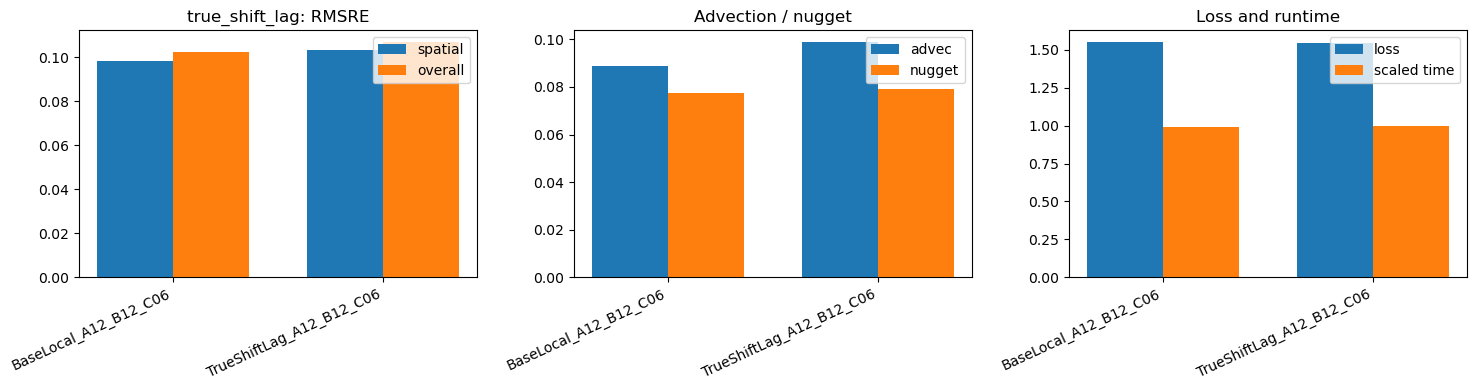

In [9]:
for group, sub in mc_summary.groupby("group", sort=False):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    x = np.arange(len(sub))
    labels = sub["model"].to_list()

    axes[0].bar(x - 0.18, sub["spatial_rmsre_mean"], width=0.36, label="spatial")
    axes[0].bar(x + 0.18, sub["overall_rmsre_mean"], width=0.36, label="overall")
    axes[0].set_title(f"{group}: RMSRE")
    axes[0].set_xticks(x, labels, rotation=25, ha="right")
    axes[0].legend()

    axes[1].bar(x - 0.18, sub["advec_rmsre_mean"], width=0.36, label="advec")
    axes[1].bar(x + 0.18, sub["nugget_re_mean"], width=0.36, label="nugget")
    axes[1].set_title("Advection / nugget")
    axes[1].set_xticks(x, labels, rotation=25, ha="right")
    axes[1].legend()

    axes[2].bar(x - 0.18, sub["loss_mean"], width=0.36, label="loss")
    axes[2].bar(x + 0.18, sub["total_s_mean"] / max(sub["total_s_mean"].max(), 1), width=0.36, label="scaled time")
    axes[2].set_title("Loss and runtime")
    axes[2].set_xticks(x, labels, rotation=25, ha="right")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


## Diagnostic Decision Rule


In [10]:
print("If TrueShiftLag wins clearly, then true transport-aligned lag neighborhoods are genuinely informative in the simulation.")
print("If BaseLocal wins or ties, then repeated local lag structure is already sufficient even when the true displacement is known.")
display(spec_df[["limit_A", "limit_B", "limit_C", "lag1_lon_shift", "lag2_lon_shift", "total_conditioning", "allocation"]])


If TrueShiftLag wins clearly, then true transport-aligned lag neighborhoods are genuinely informative in the simulation.
If BaseLocal wins or ties, then repeated local lag structure is already sufficient even when the true displacement is known.


,limit_A,limit_B,limit_C,lag1_lon_shift,lag2_lon_shift,total_conditioning,allocation
true_shift_lag::BaseLocal_A12_B12_C06,12,12,6,0.0,0.0,32,local lagged neighborhoods
true_shift_lag::TrueShiftLag_A12_B12_C06,12,12,6,0.126,0.252,32,true advection-shifted lag neighborhoods


## Interpretation

This is a simulation-only oracle experiment. The longitude grid spacing is 0.126, exactly matching the one-step true upstream displacement. The shifted model uses the true longitudinal shift for both the target location and the current-time nearest-neighbor locations at lag 1, and twice that shift at lag 2. It tests whether the scientific transport-aligned neighborhood is better than repeating the same local neighborhood through time.
